# Imports

In [1]:
from lineagetree import read_from_mastodon
import numpy as np
import matplotlib.pyplot as plt
import h5py
from skimage.segmentation import watershed

# CUSTOM FUNCTIONS
import watermasks.utils as utils
import watermasks.main as main

# TO RELOAD THEM FOR TESTING
import importlib

In [ ]:
# --- LOAD DIRECTORIES FOR DATA AND FILES ---
path_h5, path_xml, path_mast, dir_input_images, dir_output_masks = utils.paths('JR_22-10-18')

VIEW='0' # Choose dataset view

# IMPORT REG. MATRICES AND LINEAGETREE
R_of_t = utils.import_registration_mats_multiview(path_xml, 0, 500)
lT = read_from_mastodon(path_mast)

TP = 300 # Choose timepoint

# IMPORT INPUT IMAGE
with h5py.File(path_h5, "r") as f5:
    raw_image = f5[f't00{TP}'][f's0{VIEW}']['2']['cells'][:]

# CALCULATE SCALING FACTORS
shape_full_h5 = np.array([300, 1888, 2100]) # as measured in T7_3 data (dir = H:)
shape_raw_image = np.array(np.shape(raw_image))
scaling = shape_raw_image/shape_full_h5
print(f'full image shape = {shape_full_h5}\n2nd h5 layer has shape = {shape_raw_image} \n-scaling ratio is [z, y, x] = {scaling}')

# GET THE REGISTERED MASTODON POSITIONS AT CURRENT TIMEPOIN
seeds_pos, seeds_array = main.get_seeds(lT, TP, VIEW, R_of_t, scaling, raw_image)

# PREPROCCESS IMAGE TO CREATE WATERSHED INPUT
im_for_ws = main.preprocess_im(raw_image)

In [3]:
ws, all_seeds, missed_seeds, stat_table = main.ws_adaptive_mask(im_for_ws, seeds_array, min_int=np.percentile(im_for_ws.ravel(), 80), max_int=np.percentile(im_for_ws.ravel(), 99.9), 
                                                                percentage_list=[100, 99.99, 99.9, 99, 97, 95, 90, 85, 80, 75, 70, 65, 60, 55, 50, 45, 40, 35, 30, 25, 20, 15, 10])

Processing thresholds for watershed:: 100%|██████████| 23/23 [03:47<00:00,  9.90s/step]


In [4]:
from beautifultable import BeautifulTable

table = BeautifulTable()
table.columns.header = ['Percentage', 'Percentile Value', 'Found Seeds', 'Missed Seeds']
for i in range(len(stat_table)):
    table.rows.insert(i, stat_table[i])
print(table)
print(f'Out of {len(all_seeds)} anotations in total, missed seeds: {stat_table[-1][-1]}({stat_table[-1][-1]/len(all_seeds)*100:.3g}%)')

+------------+------------------+-------------+--------------+
| Percentage | Percentile Value | Found Seeds | Missed Seeds |
+------------+------------------+-------------+--------------+
|   100 %    |      516.0       |     86      |     313      |
+------------+------------------+-------------+--------------+
|  99.99 %   |      512.0       |      3      |     310      |
+------------+------------------+-------------+--------------+
|   99.9 %   |      482.0       |     20      |     290      |
+------------+------------------+-------------+--------------+
|    99 %    |      298.0       |     167     |     123      |
+------------+------------------+-------------+--------------+
|    97 %    |      151.0       |     84      |      39      |
+------------+------------------+-------------+--------------+
|    95 %    |      106.0       |     10      |      29      |
+------------+------------------+-------------+--------------+
|    90 %    |       69.0       |     13      |      16

In [ ]:
ws = main.add_lost_seeds(ws, seeds_array, missed_seeds)

In [ ]:
import napari

viewer = napari.Viewer()
viewer.add_image(im_for_ws)
viewer.add_points(seeds_pos, 3, face_color='#aaff00ff', border_color='green', size=5)
viewer.add_labels(ws)
napari.run()

Final result:

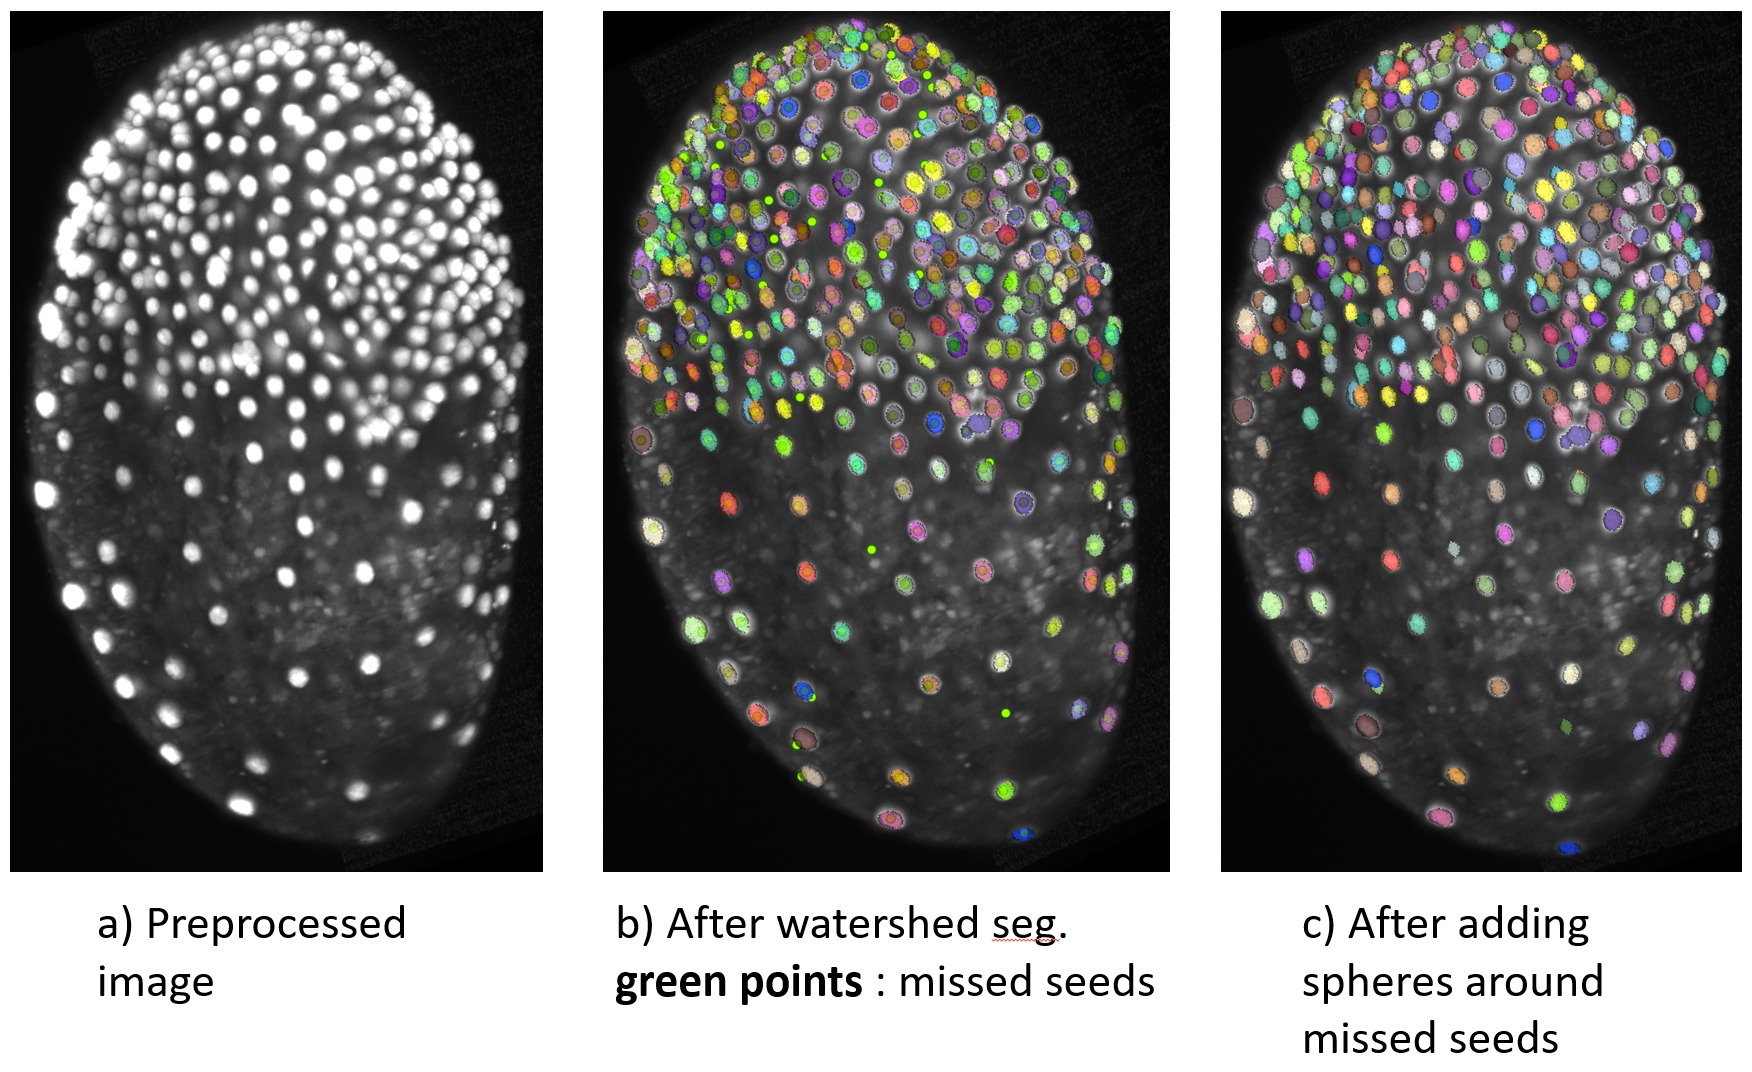